# Exp 06 — RTT time series during the SMW5 submarine-cable outage

RTT over time for each website, one line per probe, across the 12 h monitoring window.
All times converted from **UTC to Pakistan time (PKT = UTC+5, no DST)**.

Data: `results/timeseries.csv` (built by `build_timeseries.py` from the RIPE ping
measurements). Look for the international sites' RTT **falling over the window** — the
outage easing (see e.g. `shophive.com`, `telemart.pk` via PTCL).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib import cm
from pathlib import Path
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(Path('results') / 'timeseries.csv')
df['utc'] = pd.to_datetime(df['ts_utc'])
df['pkt'] = df['utc'] + pd.Timedelta(hours=5)          # Pakistan Standard Time = UTC+5
# distinct probe label (disambiguate probes that share an ISP/ASN)
df['plabel'] = (df['probe'].str.replace(r'\s*\(AS\d+\)', '', regex=True)
                + ' (' + df['probe_id'].astype(str) + ')')
df = df.sort_values('pkt')

targets = sorted(df['target'].unique())
probes  = sorted(df['plabel'].unique())
cmap = cm.get_cmap('tab20', len(probes))
pcolor = {p: cmap(i) for i, p in enumerate(probes)}

print(f"{len(df)} points | {len(targets)} sites | {len(probes)} probes")
print('window (PKT):', df['pkt'].min(), '->', df['pkt'].max())

9127 points | 15 sites | 14 probes
window (PKT): 2026-07-03 01:28:16 -> 2026-07-03 13:20:18


C:\Users\rayan\AppData\Local\Temp\ipykernel_32792\3338665760.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(probes))


## Grid — one panel per website, a line per probe

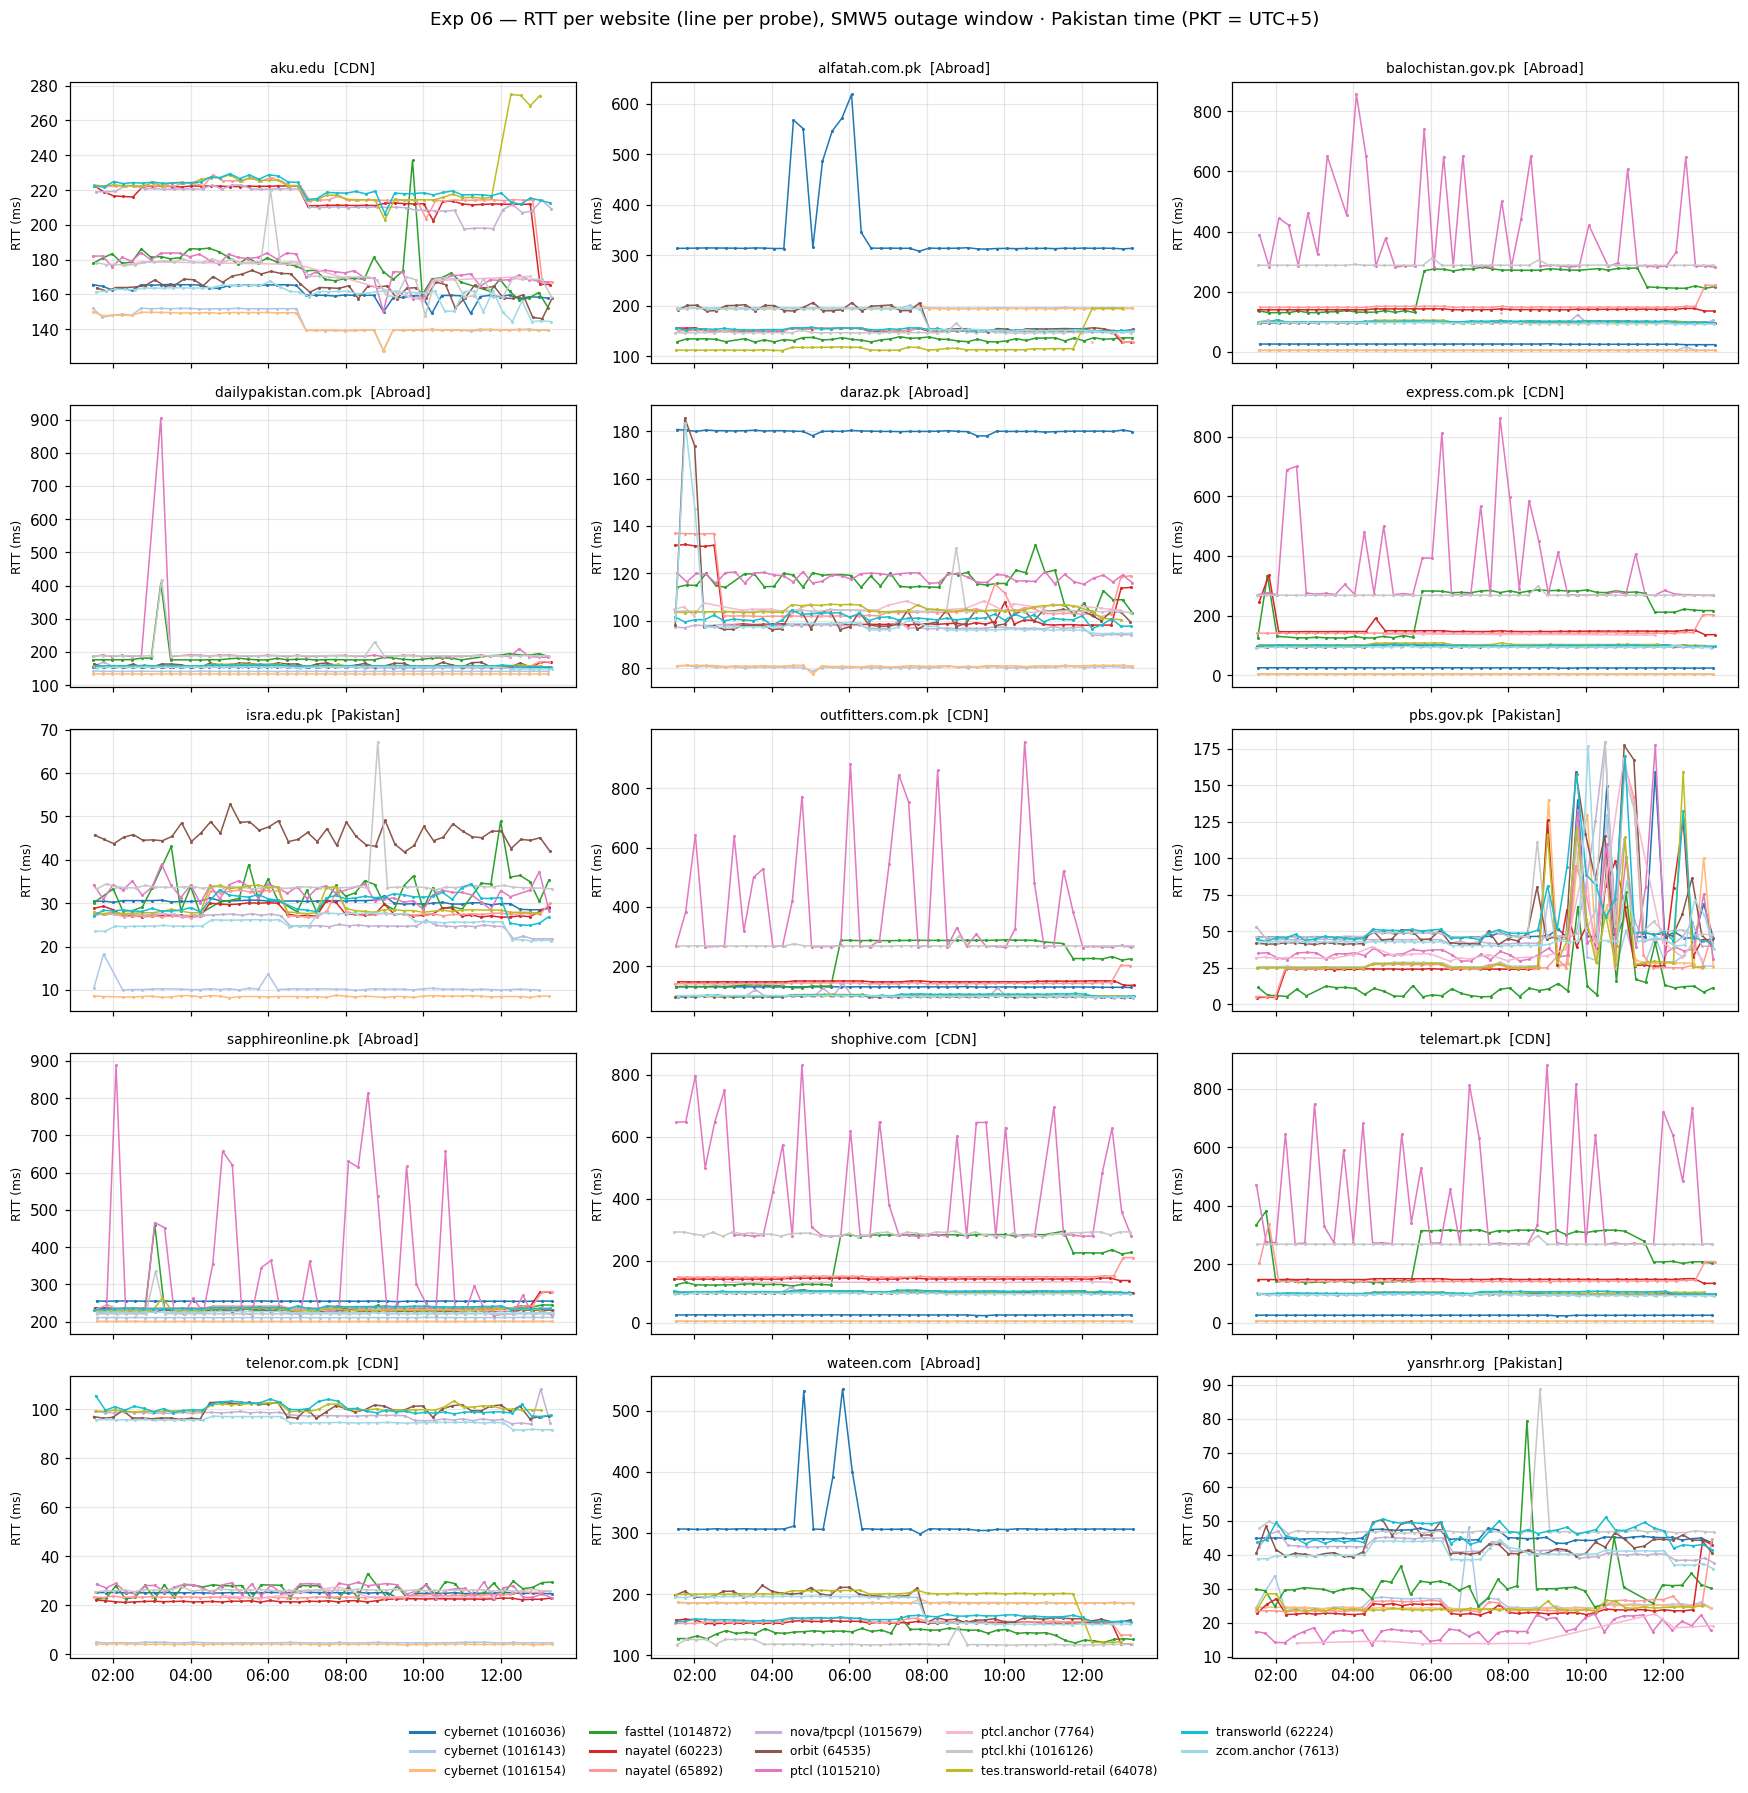

In [2]:
n = len(targets); cols = 3; rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.2 * rows), sharex=True)
axes = axes.flatten()
for ax, tg in zip(axes, targets):
    sub = df[df['target'] == tg]
    for p, g in sub.groupby('plabel'):
        ax.plot(g['pkt'], g['rtt_ms'], color=pcolor[p], lw=1, marker='.', ms=2, label=p)
    ax.set_title(f"{tg}  [{sub['cat'].iloc[0]}]", fontsize=9)
    ax.set_ylabel('RTT (ms)', fontsize=8)
    ax.grid(alpha=.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
for ax in axes[n:]:
    ax.axis('off')
handles = [plt.Line2D([0], [0], color=pcolor[p], lw=2) for p in probes]
fig.legend(handles, probes, loc='lower center', ncol=5, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Exp 06 — RTT per website (line per probe), SMW5 outage window · Pakistan time (PKT = UTC+5)',
             fontsize=12)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
Path('results/figures').mkdir(parents=True, exist_ok=True)
fig.savefig('results/figures/rtt_by_site.png', bbox_inches='tight', dpi=130)
plt.show()

## Zoom on a single website (change the name)

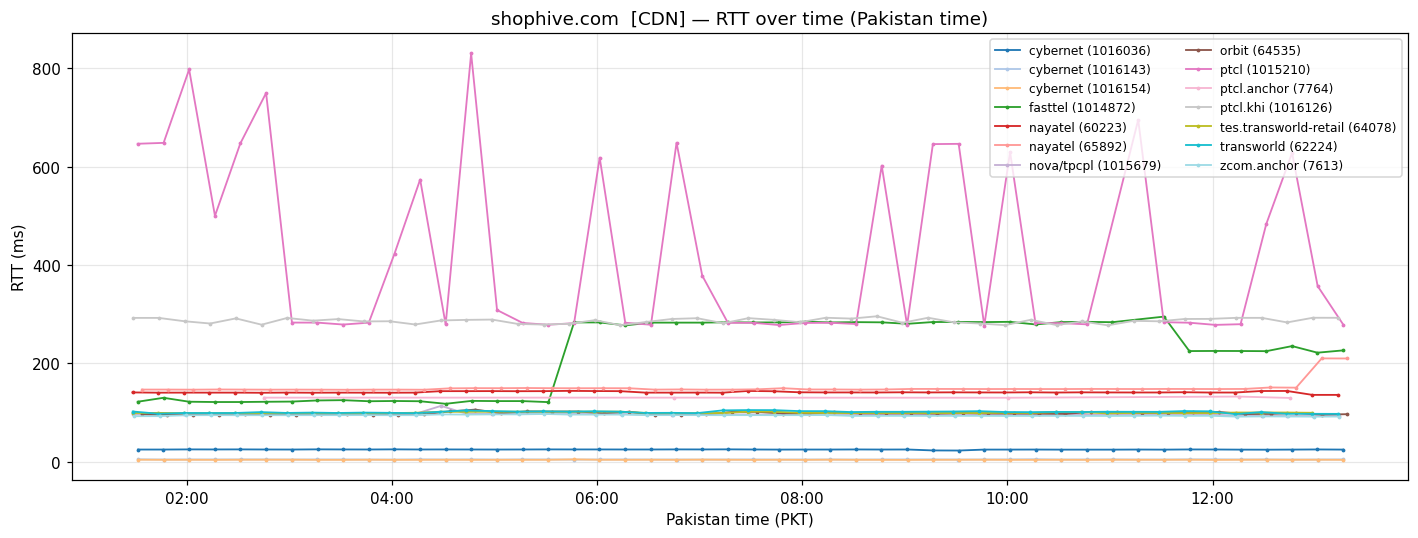

In [3]:
def plot_site(target, save=False):
    sub = df[df['target'] == target]
    fig, ax = plt.subplots(figsize=(13, 5))
    for p, g in sub.groupby('plabel'):
        ax.plot(g['pkt'], g['rtt_ms'], color=pcolor[p], marker='.', ms=3, lw=1.2, label=p)
    ax.set_title(f"{target}  [{sub['cat'].iloc[0]}] — RTT over time (Pakistan time)")
    ax.set_xlabel('Pakistan time (PKT)'); ax.set_ylabel('RTT (ms)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(alpha=.3); ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    if save:
        fig.savefig(f'results/figures/rtt_{target}.png', bbox_inches='tight', dpi=130)
    plt.show()

plot_site('shophive.com')   # the clearest recovery case (PTCL 646 -> 278 ms)

## Per-probe view — one panel per probe, a line per website

C:\Users\rayan\AppData\Local\Temp\ipykernel_32792\3304683216.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tcolor = {t: cm.get_cmap('tab20', len(targets))(i) for i, t in enumerate(targets)}


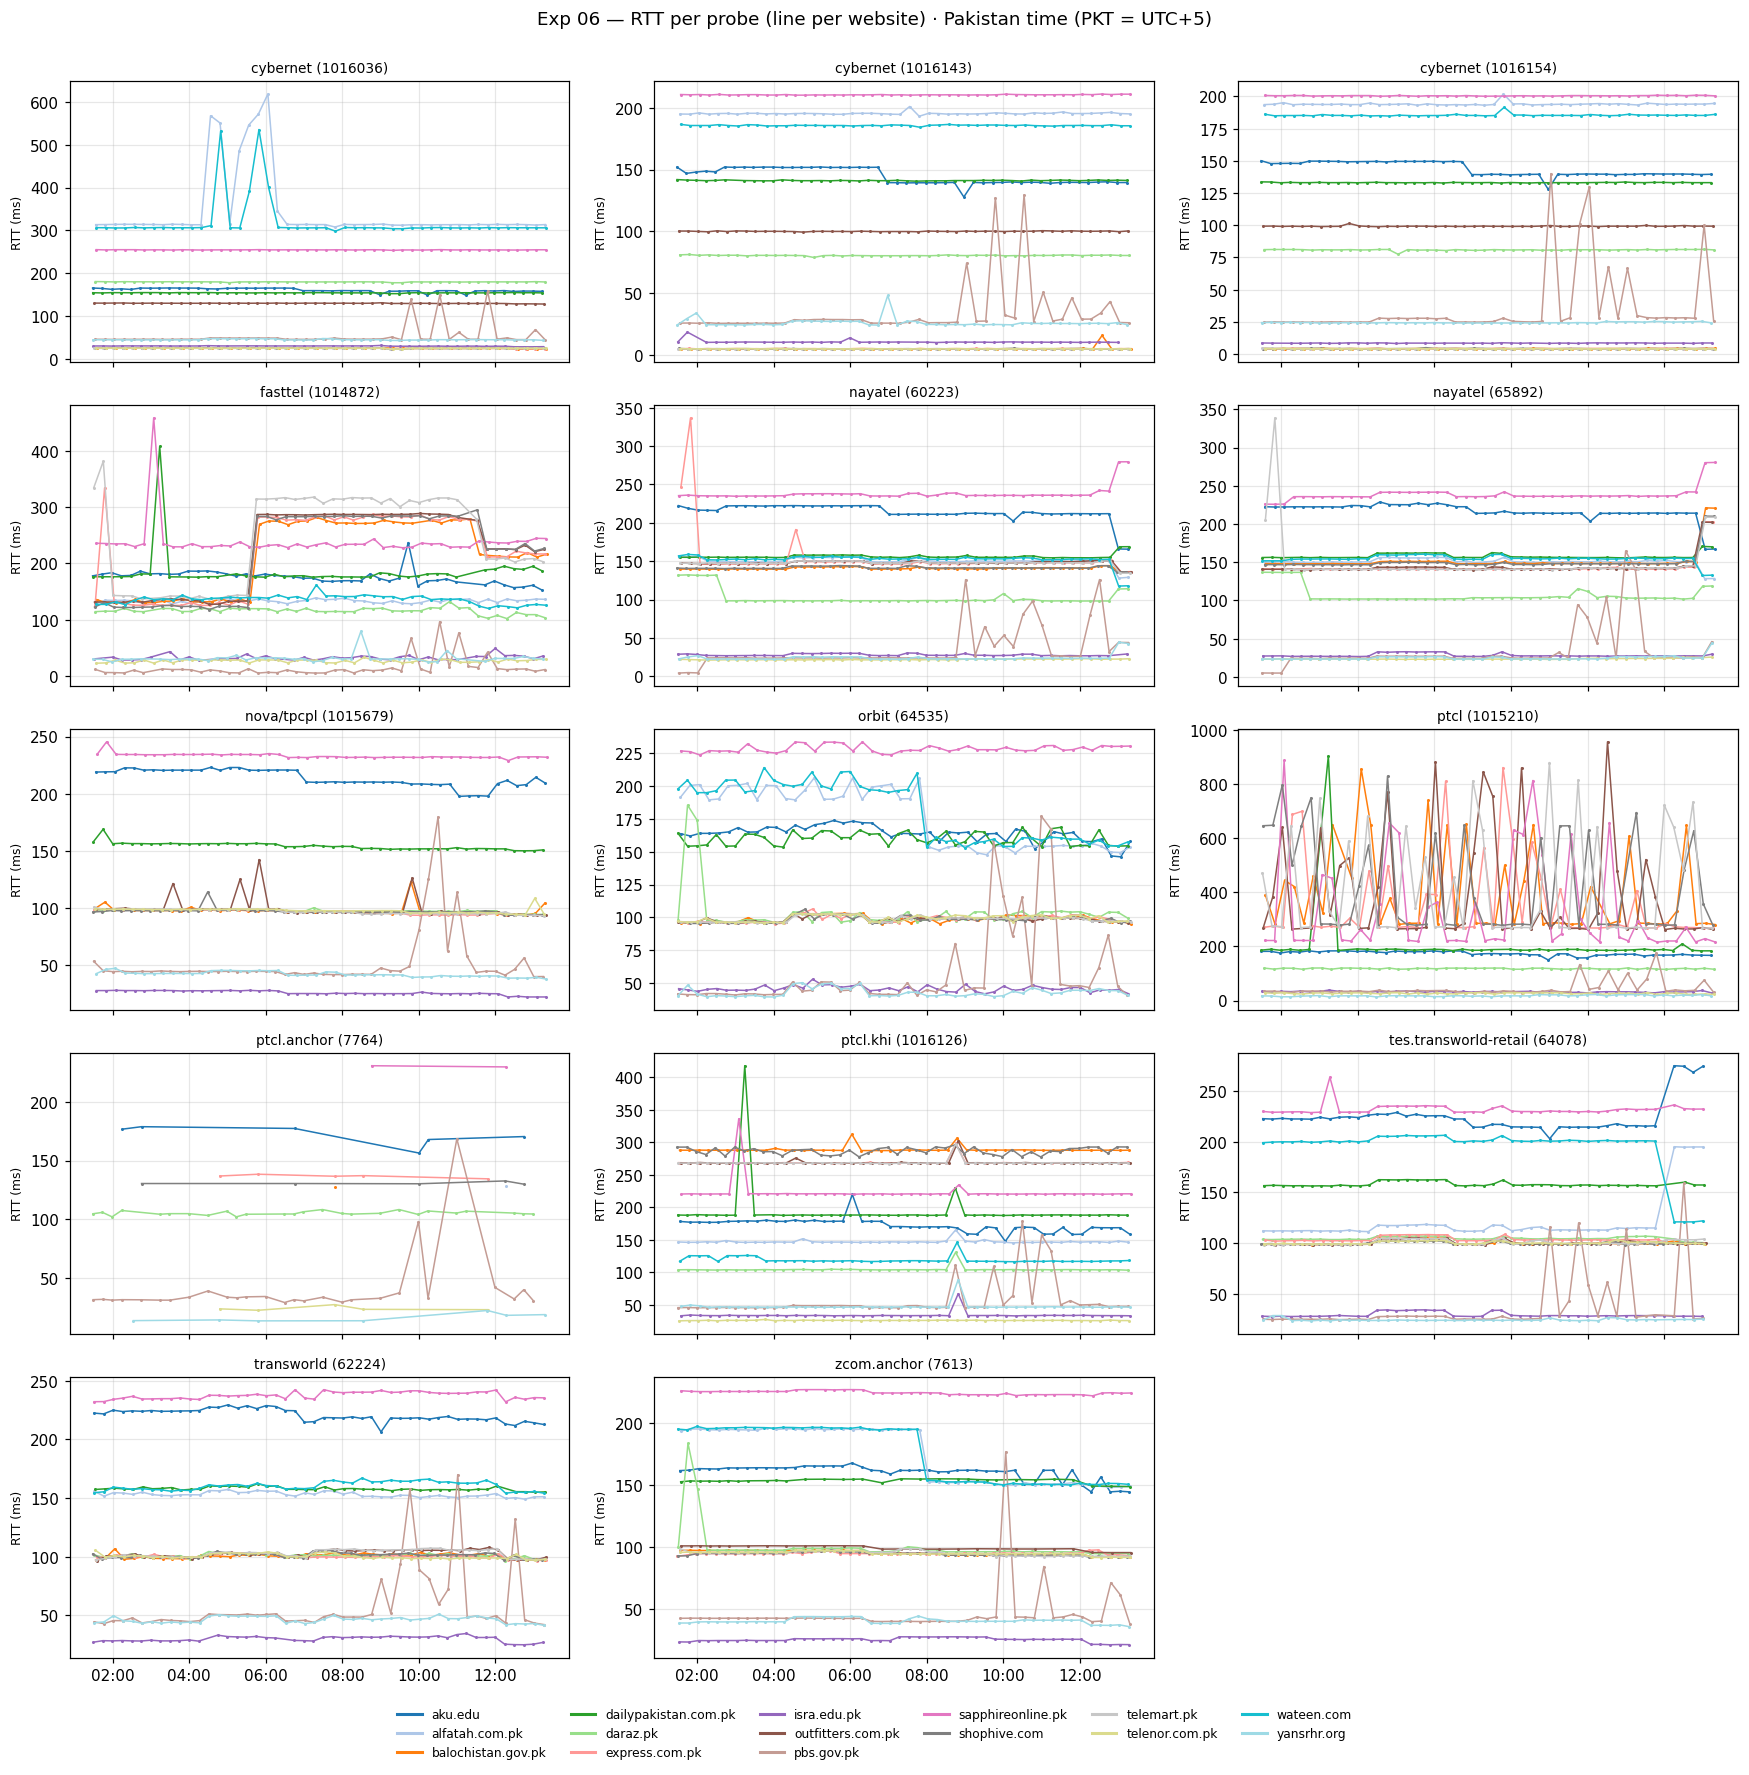

In [4]:
tcolor = {t: cm.get_cmap('tab20', len(targets))(i) for i, t in enumerate(targets)}
m = len(probes); cols = 3; rows = int(np.ceil(m / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.2 * rows), sharex=True)
axes = axes.flatten()
for ax, pr in zip(axes, probes):
    sub = df[df['plabel'] == pr]
    for t, g in sub.groupby('target'):
        ax.plot(g['pkt'], g['rtt_ms'], color=tcolor[t], lw=1, marker='.', ms=2, label=t)
    ax.set_title(pr, fontsize=9); ax.set_ylabel('RTT (ms)', fontsize=8)
    ax.grid(alpha=.3); ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
for ax in axes[m:]:
    ax.axis('off')
handles = [plt.Line2D([0], [0], color=tcolor[t], lw=2) for t in targets]
fig.legend(handles, targets, loc='lower center', ncol=6, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Exp 06 — RTT per probe (line per website) · Pakistan time (PKT = UTC+5)', fontsize=12)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.savefig('results/figures/rtt_by_probe.png', bbox_inches='tight', dpi=130)
plt.show()